In [291]:
import pandas as pd
import numpy as np
from datetime import datetime
import re
import ast
import json

# Translation Table

In [292]:
translation_table = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/translation_table_drug_disease.csv") # from Translation_02_Drug_Disease

In [293]:
translation_table.shape

(13570, 20)

In [294]:
keep_linked_only = False
if keep_linked_only:
    # Filter to keep rows where both IDs are NOT -1
    translation_table = translation_table[
        (translation_table['merged_mondo_termid'] != "-1") & 
        (translation_table['merged_umls_termid'] != "-1")
    ]
    
    # Reset index for a clean dataframe
    translation_table = translation_table.reset_index(drop=True)

In [295]:
translation_table.shape

(13570, 20)

In [296]:
translation_table.head()

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,phase,overall_status,clinical_count,preclinical_doc_ids,pub_year,preclinical_count,max_phase,min_trial_start_year,max_trial_start_year,min_phase_4_year,at_least_one_phase3,at_least_one_phase3_completed,at_least_one_phase4
0,parkinson disease <> levodopa,"['NCT00004576', 'NCT00006077', 'NCT00006337', ...",MONDO:0005180,C0023570,parkinson disease,levodopa,"[2000.0, 2000.0, 2000.0, 2001.0, 2001.0, 2002....","['Phase 2', 'Phase 2', 'Phase 2', 'Phase 2', '...","['Completed', 'Completed', 'Completed', 'Compl...",252.0,"[31915844, 31920431, 11860157, 11860478, 11860...","[2020.0, 2020.0, 2002.0, 2001.0, 2002.0, 2010....",1737.0,Phase 4,2000.0,2023.0,2002.0,True,True,True
1,schizophrenia <> risperidone,"['NCT00014001', 'NCT00018668', 'NCT00034749', ...",MONDO:0005090,C0073393,schizophrenia,risperidone,"[2000.0, 2000.0, 2001.0, 2001.0, 2002.0, 2001....","['Phase 4', 'Phase 4', 'Phase 3', 'Phase 3', '...","['Completed', 'Completed', 'Completed', 'Compl...",221.0,"[32866524, 24317442, 36744005, 19579000, 27250...","[2020.0, 2014.0, 2023.0, 2010.0, 2016.0, 2001....",454.0,Phase 4,2000.0,2023.0,2000.0,True,True,True
2,schizophrenia <> olanzapine,"['NCT00014001', 'NCT00034801', 'NCT00034892', ...",MONDO:0005090,C0171023,schizophrenia,olanzapine,"[2000.0, 2001.0, 2002.0, 2001.0, 2001.0, 2001....","['Phase 4', 'Phase 4', 'Phase 3', 'Phase 4', '...","['Completed', 'Completed', 'Completed', 'Compl...",162.0,"[32866524, 19359144, 15464760, 19059234, 28375...","[2020.0, 2009.0, 2004.0, 2009.0, 2017.0, 2014....",426.0,Phase 4,2000.0,2023.0,2000.0,True,True,True
3,schizophrenia <> aripiprazole,"['NCT00036127', 'NCT00036361', 'NCT00080327', ...",MONDO:0005090,C0299792,schizophrenia,aripiprazole,"[2002.0, 2002.0, 2003.0, 2003.0, 2004.0, 2004....","['Phase 2/Phase 3', 'Phase 3', 'Phase 4', 'Pha...","['Completed', 'Completed', 'Completed', 'Compl...",138.0,"[24317442, 24309096, 21893111, 17056032, 34332...","[2014.0, 2014.0, 2011.0, 2006.0, 2021.0, 2006....",196.0,Phase 4,2000.0,2023.0,2000.0,True,True,True
4,depressive disorder <> antidepressant,"['NCT00009191', 'NCT00018902', 'NCT00026637', ...",MONDO:0002050,-1,depressive disorder,antidepressant,"[2005.0, 2001.0, 2001.0, 2002.0, 2004.0, 2004....","['Phase 4', 'Phase 2/Phase 3', 'Phase 3', 'Pha...","['Completed', 'Completed', 'Completed', 'Compl...",131.0,"[29157077, 22983097, 33245959, 38331354, 31856...","[2018.0, 2013.0, 2021.0, 2024.0, 2019.0, 2003....",65.0,Phase 4,2000.0,2023.0,2001.0,True,True,True


In [297]:
translation_table_translated[['preclinical_doc_ids','pub_year','min_phase_4_year']]

,preclinical_doc_ids,pub_year,min_phase_4_year
0,"[31915844, 31920431, 11860157, 11860478, 11860...","[2020.0, 2020.0, 2002.0, 2001.0, 2002.0, 2010....",2002.0
1,"[32866524, 24317442, 36744005, 19579000, 27250...","[2020.0, 2014.0, 2023.0, 2010.0, 2016.0, 2001....",2000.0
2,"[32866524, 19359144, 15464760, 19059234, 28375...","[2020.0, 2009.0, 2004.0, 2009.0, 2017.0, 2014....",2000.0
3,"[24317442, 24309096, 21893111, 17056032, 34332...","[2014.0, 2014.0, 2011.0, 2006.0, 2021.0, 2006....",2000.0
4,"[29157077, 22983097, 33245959, 38331354, 31856...","[2018.0, 2013.0, 2021.0, 2024.0, 2019.0, 2003....",2001.0
...,...,...,...
13529,[16989788],[2006.0],2015.0
13530,[33839695],[2021.0],2016.0
13533,[27966748],[2016.0],2004.0
13545,[34347648],[2021.0],2023.0


### translated to phase 4

In [298]:
df_translated = translation_table[translation_table['at_least_one_phase4']==True]
df_translated.loc[:, 'min_phase_4_year'] = pd.to_numeric(df_translated['min_phase_4_year'], errors='coerce')

def to_list(x):
    if not isinstance(x, str) or not x.startswith('['):
        return x if isinstance(x, list) else []
    
    # Replace 'nan' with 'None' so the parser understands it
    cleaned_x = x.replace('nan', 'None')
    
    try:
        return ast.literal_eval(cleaned_x)
    except Exception as e:
        # If literal_eval still fails, try json.loads as a backup
        try:
            return json.loads(cleaned_x.replace("'", '"'))
        except:
            print(f"Failed to parse: {x[:50]}...") # Print first 50 chars of error
            return []

# Apply the fix
df_translated.loc[:, 'preclinical_doc_ids'] = df_translated['preclinical_doc_ids'].apply(to_list)
df_translated.loc[:, 'pub_year'] = df_translated['pub_year'].apply(to_list)

df_translated.head(2)

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,phase,overall_status,clinical_count,preclinical_doc_ids,pub_year,preclinical_count,max_phase,min_trial_start_year,max_trial_start_year,min_phase_4_year,at_least_one_phase3,at_least_one_phase3_completed,at_least_one_phase4
0,parkinson disease <> levodopa,"['NCT00004576', 'NCT00006077', 'NCT00006337', ...",MONDO:0005180,C0023570,parkinson disease,levodopa,"[2000.0, 2000.0, 2000.0, 2001.0, 2001.0, 2002....","['Phase 2', 'Phase 2', 'Phase 2', 'Phase 2', '...","['Completed', 'Completed', 'Completed', 'Compl...",252.0,"[31915844, 31920431, 11860157, 11860478, 11860...","[2020.0, 2020.0, 2002.0, 2001.0, 2002.0, 2010....",1737.0,Phase 4,2000.0,2023.0,2002.0,True,True,True
1,schizophrenia <> risperidone,"['NCT00014001', 'NCT00018668', 'NCT00034749', ...",MONDO:0005090,C0073393,schizophrenia,risperidone,"[2000.0, 2000.0, 2001.0, 2001.0, 2002.0, 2001....","['Phase 4', 'Phase 4', 'Phase 3', 'Phase 3', '...","['Completed', 'Completed', 'Completed', 'Compl...",221.0,"[32866524, 24317442, 36744005, 19579000, 27250...","[2020.0, 2014.0, 2023.0, 2010.0, 2016.0, 2001....",454.0,Phase 4,2000.0,2023.0,2000.0,True,True,True


In [299]:
df_translated['preclinical_ids_before_p4'] = df_translated.apply(
    lambda row: [
        doc_id for doc_id, year in zip(row['preclinical_doc_ids'], row['pub_year']) 
        if pd.notnull(row['min_phase_4_year']) and pd.notnull(year) and float(year) <= row['min_phase_4_year']
    ], 
    axis=1
)
df_translated['preclinical_count_before_p4'] = df_translated['preclinical_ids_before_p4'].str.len()
df_translated.shape

/tmp/ipykernel_447423/3241193479.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_translated['preclinical_ids_before_p4'] = df_translated.apply(
/tmp/ipykernel_447423/3241193479.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_translated['preclinical_count_before_p4'] = df_translated['preclinical_ids_before_p4'].str.len()


(3903, 22)

In [300]:
len(df_translated[df_translated['preclinical_count_before_p4']==0]), df_translated['preclinical_count_before_p4'].sum()

(1233, 27915)

In [301]:
translated_pmids = list(set([
    pmid 
    for sublist in df_translated['preclinical_ids_before_p4'] 
    for pmid in sublist
]))
len(translated_pmids)

18696

In [302]:
translated_pmids[:5]

[29163523, 18284547, 20676611, 23691275, 28606476]

### no phase 4 (and not recently entered clinical)

In [303]:
df_failed = translation_table[translation_table['at_least_one_phase4']!=True]
df_failed = df_failed[df_failed['min_trial_start_year']<2015]
df_failed.shape

(5878, 20)

In [304]:
df_failed.loc[:, 'max_trial_start_year'] = pd.to_numeric(df_failed['max_trial_start_year'], errors='coerce')
df_failed.loc[:, 'preclinical_doc_ids'] = df_failed['preclinical_doc_ids'].apply(to_list)
df_failed.loc[:, 'pub_year'] = df_failed['pub_year'].apply(to_list)

In [305]:
df_failed['preclinical_ids_before_latest_trial'] = df_failed.apply(
    lambda row: [
        doc_id for doc_id, year in zip(row['preclinical_doc_ids'], row['pub_year']) 
        if pd.notnull(row['max_trial_start_year']) and pd.notnull(year) and float(year) <= row['max_trial_start_year']
    ], 
    axis=1
)
df_failed['preclinical_count_before_latest_trial'] = df_failed['preclinical_ids_before_latest_trial'].str.len()
df_failed.shape

(5878, 22)

In [306]:
df_failed.head(2)

,normalized_key,clinical_doc_ids,merged_mondo_termid,merged_umls_termid,merged_mondo_label,merged_umls_label,trial_start_year,phase,overall_status,clinical_count,...,preclinical_count,max_phase,min_trial_start_year,max_trial_start_year,min_phase_4_year,at_least_one_phase3,at_least_one_phase3_completed,at_least_one_phase4,preclinical_ids_before_latest_trial,preclinical_count_before_latest_trial
80,drug dependence <> cocaine,"['NCT00032916', 'NCT00033059', 'NCT00033098', ...",MONDO:0005303,C0009170,drug dependence,cocaine,"[2001.0, 2001.0, 2001.0, 2003.0, 2003.0, 2004....","['Phase 1', 'Phase 1', 'Phase 1', 'Phase 1', '...","['Unknown status', 'Unknown status', 'Unknown ...",35.0,...,45.0,Phase 2,2001.0,2018.0,NaN,False,False,False,"[21790900, 29227643, 10485969, 21206484, 15713...",35
98,cocaine dependence <> cocaine,"['NCT00032916', 'NCT00033059', 'NCT00033098', ...",MONDO:0005186,C0009170,cocaine dependence,cocaine,"[2001.0, 2001.0, 2001.0, 2003.0, 2003.0, 2004....","['Phase 1', 'Phase 1', 'Phase 1', 'Phase 1', '...","['Unknown status', 'Unknown status', 'Unknown ...",33.0,...,43.0,Phase 2,2001.0,2018.0,NaN,False,False,False,"[21790900, 29227643, 10485969, 21206484, 15713...",33


In [307]:
failed_pmids = list(set([
    pmid 
    for sublist in df_failed['preclinical_ids_before_latest_trial'] 
    for pmid in sublist
]))
len(failed_pmids)

22504

# Preclinical annotations

In [308]:
base_annotation_dir = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions"

df_path_current_dataset = f"{base_annotation_dir}/full_text_combined_all_annotations.csv"
preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title','disease_term_mondo_norm','drug_term_umls_norm', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_age','animal_strain','animal_number', 'assay_type', 'first_author_country']]
preclin_dataset['animal_sex'] = preclin_dataset['animal_sex'].apply(lambda x:x.replace("sex-",""))
primekg_cleaned = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv")
preclin_dataset = preclin_dataset.merge(primekg_cleaned[['PMID','merged_mondo_label','merged_umls_label']], on="PMID", how="left")

preclin_dataset.head()

/tmp/ipykernel_447423/904396314.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title','disease_term_mondo_norm','drug_term_umls_norm', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_age','animal_strain','animal_number', 'assay_type', 'first_author_country']]


,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_age,animal_strain,animal_number,assay_type,first_author_country,merged_mondo_label,merged_umls_label
0,157,Mechanisms of glycolytic inhibition in ischemi...,ischemic disease,Lactate,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,male,not reported,Sprague-Dawley,not reported,Histology,unlabeled,ischemic disease,Lactate
1,2163,Methanol poisoning. I. The role of formic acid...,metabolic acidosis|poisoning,Fomepizole,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,monkey,both,2.2-6.5 years,Sprague-Dawley,not reported,"Behavioral, Molecular & Cellular",unlabeled,metabolic acidosis|poisoning,Fomepizole
2,2617,A rabbit reticulocyte model for the role of he...,hypochromic anemia,Ethanol,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rabbit,not-reported,not reported,not reported,not reported,Molecular & Cellular,unlabeled,hypochromic anemia,Ethanol
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Phenytoin|Pentobarbital,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,not-reported,not reported,not reported,2.0,not reported,unlabeled,epilepsy,Phenytoin|Pentobarbital
4,3420,"Anti-arrhythmic action of nadolol, a beta-adre...",ventricular arrhythmias due to cardiac ryanodi...,beta-adrenergic receptor blocking agent|Nadolo...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"cat, dog",male,not reported,Mongrel,not reported,"Molecular & Cellular, Physiology",unlabeled,ventricular arrhythmias due to cardiac ryanodi...,"Propranolol|2 , 3-cis-1 , 2 , 3 , 4-tetrahydro..."


### translated subset

In [309]:
df_translated_rel = df_translated[['normalized_key', 'preclinical_ids_before_p4']]

# Explode the list column into individual rows
df_translated_exploded = df_translated_rel.explode('preclinical_ids_before_p4')
df_translated_exploded = df_translated_exploded.reset_index(drop=True)
df_translated_exploded = df_translated_exploded.rename(columns={'preclinical_ids_before_p4': 'pmid'})

df_translated_exploded = df_translated_exploded.dropna(subset=['pmid'])
df_translated_exploded.head()

,normalized_key,pmid
0,parkinson disease <> levodopa,11860157
1,parkinson disease <> levodopa,11860478
2,parkinson disease <> levodopa,11860512
3,parkinson disease <> levodopa,8210221
4,parkinson disease <> levodopa,9565967


In [310]:
filtered_preclin_df_translated = pd.merge(
    df_translated_exploded, 
    preclin_dataset, 
    left_on='pmid', 
    right_on='PMID', 
    how='inner'
)

# 3. Clean up
# Since we have both 'pmid' and 'PMID' columns now, we can drop the lowercase one
filtered_preclin_df_translated = filtered_preclin_df_translated.drop(columns=['pmid']).reset_index(drop=True)

print(f"Total rows after joining with PMIDs: {len(filtered_preclin_df_translated)} / {filtered_preclin_df_translated.PMID.nunique()}")

Total rows after joining with PMIDs: 16453 / 11178


In [311]:
filtered_preclin_df_translated['study_classification'] = "approved"

filtered_preclin_df_translated.head()

,normalized_key,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_age,animal_strain,animal_number,assay_type,first_author_country,merged_mondo_label,merged_umls_label,study_classification
0,parkinson disease <> levodopa,11860512,Pharmacological validation of behavioural meas...,Parkinson disease,Levodopa|Clozapine|Amantadine|Yohimbine|5-meth...,blinding-present,randomization-not-reported,welfare-present,sample-size-not-reported,rat,female,not reported,Sprague-Dawley,"[36.0, 69.0]","Behavioral, Molecular & Cellular",Sweden,Parkinson disease,Levodopa|Bromocriptine|Yohimbine|Naloxone|Cloz...,approved
1,parkinson disease <> amantadine,11860512,Pharmacological validation of behavioural meas...,Parkinson disease,Levodopa|Clozapine|Amantadine|Yohimbine|5-meth...,blinding-present,randomization-not-reported,welfare-present,sample-size-not-reported,rat,female,not reported,Sprague-Dawley,"[36.0, 69.0]","Behavioral, Molecular & Cellular",Sweden,Parkinson disease,Levodopa|Bromocriptine|Yohimbine|Naloxone|Cloz...,approved
2,parkinson disease <> bromocriptine,11860512,Pharmacological validation of behavioural meas...,Parkinson disease,Levodopa|Clozapine|Amantadine|Yohimbine|5-meth...,blinding-present,randomization-not-reported,welfare-present,sample-size-not-reported,rat,female,not reported,Sprague-Dawley,"[36.0, 69.0]","Behavioral, Molecular & Cellular",Sweden,Parkinson disease,Levodopa|Bromocriptine|Yohimbine|Naloxone|Cloz...,approved
3,parkinson disease <> levodopa,8210221,Antiparkinsonian effects of remacemide hydroch...,Parkinson disease,glutamate receptor antagonist|levodopa-carbido...,blinding-present,randomization-not-reported,welfare-present,sample-size-not-reported,"monkey, rat",female,not reported,"Rutj,Sprague-Dawley",not reported,not reported,USA,Parkinson disease,n-methyl-d-aspartate receptor antagonists|levo...,approved
4,parkinson disease <> carbidopa,8210221,Antiparkinsonian effects of remacemide hydroch...,Parkinson disease,glutamate receptor antagonist|levodopa-carbido...,blinding-present,randomization-not-reported,welfare-present,sample-size-not-reported,"monkey, rat",female,not reported,"Rutj,Sprague-Dawley",not reported,not reported,USA,Parkinson disease,n-methyl-d-aspartate receptor antagonists|levo...,approved


### failed subset

In [312]:
docs_col = "preclinical_ids_before_latest_trial"
df_failed_rel = df_failed[['normalized_key', docs_col]] #preclinical_doc_ids

# Explode the list column into individual rows
df_failed_exploded = df_failed_rel.explode(docs_col)
df_failed_exploded = df_failed_exploded.reset_index(drop=True)
df_failed_exploded = df_failed_exploded.rename(columns={docs_col: 'pmid'})

df_failed_exploded = df_failed_exploded.dropna(subset=['pmid'])
df_failed_exploded.head()

,normalized_key,pmid
0,drug dependence <> cocaine,21790900
1,drug dependence <> cocaine,29227643
2,drug dependence <> cocaine,10485969
3,drug dependence <> cocaine,21206484
4,drug dependence <> cocaine,15713268


In [313]:
filtered_preclin_df_failed = pd.merge(
    df_failed_exploded, 
    preclin_dataset, 
    left_on='pmid', 
    right_on='PMID', 
    how='inner'
)

# 3. Clean up
# Since we have both 'pmid' and 'PMID' columns now, we can drop the lowercase one
filtered_preclin_df_failed = filtered_preclin_df_failed.drop(columns=['pmid']).reset_index(drop=True)
filtered_preclin_df_failed['study_classification'] = "failed"

print(f"Total rows after joining with PMIDs: {len(filtered_preclin_df_failed)} / {filtered_preclin_df_failed.PMID.nunique()}")

Total rows after joining with PMIDs: 18272 / 13840


### concat

In [314]:
# Append the translated rows to the failed rows
combined_preclin_df = pd.concat([filtered_preclin_df_failed, filtered_preclin_df_translated], axis=0)

# Highly recommended: Reset the index
combined_preclin_df = combined_preclin_df.reset_index(drop=True)

In [315]:
combined_preclin_df.shape

(34725, 19)

In [316]:
# Count how many PMID values are repeated
duplicate_count = combined_preclin_df.duplicated(subset=['PMID']).sum()

print(f"Number of duplicate PMIDs: {duplicate_count}")

Number of duplicate PMIDs: 11879


In [317]:
combined_preclin_df.head()

,normalized_key,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_age,animal_strain,animal_number,assay_type,first_author_country,merged_mondo_label,merged_umls_label,study_classification
0,drug dependence <> cocaine,21790900,Addictive potential of modafinil and cross-sen...,narcolepsy|cocaine dependence,Cocaine|modafinil,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,13 weeks,SwissEpmM1,"[22.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,narcolepsy|cocaine dependence|drug dependence,Cocaine|modafinil,failed
1,cocaine dependence <> cocaine,21790900,Addictive potential of modafinil and cross-sen...,narcolepsy|cocaine dependence,Cocaine|modafinil,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,13 weeks,SwissEpmM1,"[22.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,narcolepsy|cocaine dependence|drug dependence,Cocaine|modafinil,failed
2,drug dependence <> modafinil,21790900,Addictive potential of modafinil and cross-sen...,narcolepsy|cocaine dependence,Cocaine|modafinil,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,13 weeks,SwissEpmM1,"[22.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,narcolepsy|cocaine dependence|drug dependence,Cocaine|modafinil,failed
3,cocaine dependence <> modafinil,21790900,Addictive potential of modafinil and cross-sen...,narcolepsy|cocaine dependence,Cocaine|modafinil,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,13 weeks,SwissEpmM1,"[22.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,narcolepsy|cocaine dependence|drug dependence,Cocaine|modafinil,failed
4,drug dependence <> cocaine,29227643,Structure-Activity Relationship Studies on a S...,cocaine dependence,atypical dopamine transporter (dat) inhibitors...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"mouse, rat",male,not reported,"Sprague-Dawley,SwissWebster",not reported,Molecular & Cellular,USA,cocaine dependence|drug dependence,3α-[bis (4-fluorophenyl) methoxy] tropanes|dat...,failed


# Translation stats

In [318]:
def to_pct(val):
    if pd.isna(val):
        return np.nan
    # already numeric: assume 0–1 are proportions, >=1 are percent values
    if isinstance(val, (int, float)):
        return float(val) * 100 if 0 <= float(val) <= 1 else float(val)
    s = str(val).strip()
    # match "(40.0%)" inside text like "6 (40.0%)"
    m = re.search(r'\(([-+]?\d*\.?\d+)\s*%?\)', s)
    if m:
        return float(m.group(1))
    # match trailing "40%" or "40.0 %"
    m = re.search(r'([-+]?\d*\.?\d+)\s*%$', s)
    if m:
        return float(m.group(1))
    # fallback: try raw float
    try:
        return float(s)
    except ValueError:
        return np.nan

In [334]:
def _tokens(s):
    if pd.isna(s) or not str(s).strip():
        return set()
    return {t.strip() for t in _splitter.split(str(s)) if t.strip()}

def _strip_prefix_lower(x):
    x = x.lower().strip()
    x = re.sub(r'^(sex|species|strain|assay|country|first_author_country)[\s\-_]*', '', x)
    return x


def _sex_norms(sex_str):
    toks = {_strip_prefix_lower(t) for t in _tokens(sex_str)}
    out = set()
    for t in toks:
        if 'both' in t:        out.add('both')
        elif 'male' in t:      out.add('male')
        if 'female' in t:    out.add('female')
        if 'not' in t and 'report' in t:
            out.add('not-reported')
        elif t:
            out.add(t)
    return out
    
def compute_flags(row):
    sexes = _sex_norms(row.get('animal_sex'))
    both_sexes = ('both' in sexes) or ('male' in sexes and 'female' in sexes)

    species = _clean_set(row.get('animal_species'), exclude={'other','not reported'})  # exclude species-other
    strains = _clean_set(row.get('animal_strain'),  exclude={'unlabeled','unlabelled', 'not reported'})
    assays  = _clean_set(row.get('assay_type'),     exclude={'unlabeled','unlabelled', 'not reported'})
    countries = _clean_set(row.get('first_author_country'), exclude={'unlabeled','unlabelled','not reported'})

    return pd.Series({
        'tested_both_sexes': int(both_sexes),
        'species_unique': len(species),
        'species_ge2': int(len(species) >= 2),
        'strain_unique': len(strains),
        'strains_ge2': int(len(strains) >= 2),
        'assay_unique': len(assays),
        'assays_ge2': int(len(assays) >= 2),
        'country_unique': len(countries),
        'countries_ge2': int(len(countries) >= 2),
    })

def fmt_count_pct(count, total):
    pct = (count / total * 100) if total > 0 else 0
    return f"{count} ({pct:.1f}%)"
    
def _clean_set(cat_str, exclude=None):
    exclude = exclude or set()
    toks = {_strip_prefix_lower(t) for t in _tokens(cat_str)}
    return {t for t in toks if t and t not in exclude}
    
def unique_concat(series):
    vals = set()
    for x in series.dropna():
        for t in _splitter.split(str(x)):
            if t.strip():
                vals.add(t.strip())
    return ', '.join(sorted(vals)) if vals else ''

_splitter = re.compile(r'[|,]')

def get_heterogeneity_stats(df, agg_dict, drug_col_name, study_id_col="PMID"):

    table_by_drug = (df
      .groupby(drug_col_name, dropna=False)
      .agg(**agg_dict)
      .reset_index()
      .rename(columns={drug_col_name: 'drug_name'}))

    # flags + aggregates for non-approved
    per_drug_flags = table_by_drug.apply(compute_flags, axis=1)
    total_drugs = len(table_by_drug)
    
    aggregate_stats = pd.Series({
        'n_entities_in_table': total_drugs,
        'tested_in_both_sexes': fmt_count_pct(int(per_drug_flags['tested_both_sexes'].sum()), total_drugs),
        'tested_in_>=2_species': fmt_count_pct(int(per_drug_flags['species_ge2'].sum()), total_drugs),
        'tested_in_>=2_strains': fmt_count_pct(int(per_drug_flags['strains_ge2'].sum()), total_drugs),
        'tested_with_>=2_outcomes': fmt_count_pct(int(per_drug_flags['assays_ge2'].sum()), total_drugs),
        'tested_in_>=2_countries': fmt_count_pct(int(per_drug_flags['countries_ge2'].sum()), total_drugs),
    })
    
    # study-level totals & rigor % for the filtered non-approved subset (unique studies only)
    total_studies_non = int(df[study_id_col].nunique())
    aggregate_stats.loc['total_number_of_studies'] = total_studies_non

    return aggregate_stats, table_by_drug, per_drug_flags

def pick_rig_cols(columns):
    order = [('rigor_blinding_binary','rigor_blinding'),
             ('rigor_randomization_binary','rigor_randomization'),
             ('rigor_welfare_binary','rigor_welfare')]
    picked = []
    for a,b in order:
        picked.append(a if a in columns else (b if b in columns else None))
    return picked

def pct(n, d):
    return f"{(n/d*100):.1f}%" if d > 0 else "0.0%"


def rob_percents_per_subset(df_subset, pick_rig_cols_fn):
    """Compute % of studies (unique PMIDs) with each ROB flag."""
    rb_col, rr_col, rw_col = pick_rig_cols_fn(df_subset.columns)
    rig_cols = [c for c in [rb_col, rr_col, rw_col] if c]

    if not rig_cols:
        return {"%_rigor_blinding": "0.0%", "%_rigor_randomization": "0.0%", "%_rigor_welfare": "0.0%"}

    tmp = df_subset[["PMID"] + rig_cols].copy()
    for c in rig_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce").fillna(0).astype(int).clip(0, 1)

    # One record per study: a study counts as 1 if ANY row says 1
    per_study = tmp.groupby("PMID", as_index=False)[rig_cols].max()
    n_studies = len(per_study)

    rb = per_study[rb_col].sum() if rb_col else 0
    rr = per_study[rr_col].sum() if rr_col else 0
    rw = per_study[rw_col].sum() if rw_col else 0

    return {
        "%_rigor_blinding": pct(rb, n_studies),
        "%_rigor_randomization": pct(rr, n_studies),
        "%_rigor_welfare": pct(rw, n_studies),
    }

    
def compute_experimental_chars(df, agg_dict, drug_col="unique_drug_target"):

    # FAILED DRUGS
    non_approved_studies = df[(df['study_classification'] != 'approved')].copy()
    print(f"Size of failed ds {non_approved_studies.shape} with {non_approved_studies[drug_col].nunique()} drugs and {non_approved_studies['PMID'].nunique()} studies")
    aggregate_stats_non_approved, table_by_drug_fail, per_drug_flags_fail = get_heterogeneity_stats(non_approved_studies, agg_dict, drug_col_name=drug_col)
    # ROB
    failed_rob = rob_percents_per_subset(non_approved_studies, pick_rig_cols)
    aggregate_stats_non_approved.loc['%_rigor_blinding']     = failed_rob['%_rigor_blinding']
    aggregate_stats_non_approved.loc['%_rigor_randomization'] = failed_rob['%_rigor_randomization']
    aggregate_stats_non_approved.loc['%_rigor_welfare']       = failed_rob['%_rigor_welfare']


    # SUCCESFULL DRUGS
    approved_matches = df[(df['study_classification'] == 'approved')].copy()
    print(f"Size of approved ds {approved_matches.shape} with {approved_matches[drug_col].nunique()} drugs and {approved_matches['PMID'].nunique()} studies")
    aggregate_stats_approved, table_by_drug_appr, per_drug_flags_appr = get_heterogeneity_stats(approved_matches, agg_dict, drug_col_name=drug_col)

    # ROB
    approved_rob = rob_percents_per_subset(approved_matches, pick_rig_cols)
    aggregate_stats_approved.loc['%_rigor_blinding']     = approved_rob['%_rigor_blinding']
    aggregate_stats_approved.loc['%_rigor_randomization'] = approved_rob['%_rigor_randomization']
    aggregate_stats_approved.loc['%_rigor_welfare']       = approved_rob['%_rigor_welfare']
    
    # -----------------------------
    # Side-by-side comparison (no .T)
    # -----------------------------
    comparison_df = pd.DataFrame({
        'Approved': aggregate_stats_approved,
        'Non-approved': aggregate_stats_non_approved
    })

    # rows for which we want the delta
    delta_rows = ['tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains', 'tested_with_>=2_outcomes', 'tested_in_>=2_countries', '%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare']
    delta_rows = [r for r in delta_rows if r in comparison_df.index]  # keep only existing
    
    # compute percentage columns for those rows
    pct_only = comparison_df.loc[delta_rows].applymap(to_pct)
    
    # add a signed percentage-point delta column: Approved - Non-approved
    comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)'] = (
        pct_only['Approved'] - pct_only['Non-approved']
    )
    
    # (optional) pretty formatting for the delta column
    comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)'] = (
        comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)']
        .apply(lambda x: f"{x:+.1f} %" if pd.notna(x) else "")
    )
    
    # keep your preferred row order
    order = [
        'n_entities_in_table',
        'total_number_of_studies',
        'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
    ]
    existing = [r for r in order if r in comparison_df.index]
    comparison_df = comparison_df.loc[existing + [i for i in comparison_df.index if i not in existing]]

    # Optional: tidy row order
    order = [
        'n_entities_in_table',
        'total_number_of_studies',
        'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
        'tested_with_>=2_outcomes', 'tested_in_>=2_countries',
        '%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare'
    ]
    existing = [r for r in order if r in comparison_df.index]
    comparison_df = comparison_df.loc[existing + [i for i in comparison_df.index if i not in existing]]
    

    return aggregate_stats_non_approved, aggregate_stats_approved, comparison_df, table_by_drug_fail, table_by_drug_appr, per_drug_flags_fail, per_drug_flags_appr




In [320]:
rigor_cols = ['rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size']
for col in rigor_cols:
    combined_preclin_df[col + '_binary'] = combined_preclin_df[col].apply(lambda x: 1 if isinstance(x, str) and 'present' in x else 0)

In [321]:
combined_preclin_df.columns

Index(['normalized_key', 'PMID', 'title', 'disease_term_mondo_norm',
       'drug_term_umls_norm', 'rigor_blinding', 'rigor_randomization',
       'rigor_welfare', 'sample_size', 'animal_species', 'animal_sex',
       'animal_age', 'animal_strain', 'animal_number', 'assay_type',
       'first_author_country', 'merged_mondo_label', 'merged_umls_label',
       'study_classification', 'rigor_blinding_binary',
       'rigor_randomization_binary', 'rigor_welfare_binary',
       'sample_size_binary'],
      dtype='object')

In [322]:
combined_preclin_df.head()

,normalized_key,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,...,animal_number,assay_type,first_author_country,merged_mondo_label,merged_umls_label,study_classification,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary,sample_size_binary
0,drug dependence <> cocaine,21790900,Addictive potential of modafinil and cross-sen...,narcolepsy|cocaine dependence,Cocaine|modafinil,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,...,"[22.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,narcolepsy|cocaine dependence|drug dependence,Cocaine|modafinil,failed,0,1,1,0
1,cocaine dependence <> cocaine,21790900,Addictive potential of modafinil and cross-sen...,narcolepsy|cocaine dependence,Cocaine|modafinil,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,...,"[22.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,narcolepsy|cocaine dependence|drug dependence,Cocaine|modafinil,failed,0,1,1,0
2,drug dependence <> modafinil,21790900,Addictive potential of modafinil and cross-sen...,narcolepsy|cocaine dependence,Cocaine|modafinil,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,...,"[22.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,narcolepsy|cocaine dependence|drug dependence,Cocaine|modafinil,failed,0,1,1,0
3,cocaine dependence <> modafinil,21790900,Addictive potential of modafinil and cross-sen...,narcolepsy|cocaine dependence,Cocaine|modafinil,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,...,"[22.0, 50.0, 52.0, 24.0]","Behavioral, Molecular & Cellular",Brazil,narcolepsy|cocaine dependence|drug dependence,Cocaine|modafinil,failed,0,1,1,0
4,drug dependence <> cocaine,29227643,Structure-Activity Relationship Studies on a S...,cocaine dependence,atypical dopamine transporter (dat) inhibitors...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"mouse, rat",...,not reported,Molecular & Cellular,USA,cocaine dependence|drug dependence,3α-[bis (4-fluorophenyl) methoxy] tropanes|dat...,failed,0,0,0,0


In [336]:
agg_dict = {
    'animal_sex': ('animal_sex', unique_concat),
    'animal_strain': ('animal_strain', unique_concat),
    'animal_species': ('animal_species', unique_concat),
    'assay_type': ('assay_type', unique_concat),
    'first_author_country': ('first_author_country', unique_concat),
    #'n_studies': ('single_drug', 'size'),
}

aggregate_stats_non_approved, aggregate_stats_approved, comparison_df, table_by_drug_fail, table_by_drug_appr, per_drug_flags_fail, per_drug_flags_appr = compute_experimental_chars(combined_preclin_df, agg_dict, drug_col="normalized_key")

comparison_df

Size of failed ds (18272, 23) with 2947 drugs and 13840 studies
Size of approved ds (16453, 23) with 2196 drugs and 11178 studies


,Approved,Non-approved,Δ % (Apprv - Non-apprv)
n_entities_in_table,2196,2947,NaN
total_number_of_studies,11178,13840,NaN
tested_in_both_sexes,899 (40.9%),1226 (41.6%),-0.7 %
tested_in_>=2_species,1084 (49.4%),1282 (43.5%),+5.9 %
tested_in_>=2_strains,1184 (53.9%),1428 (48.5%),+5.4 %
tested_with_>=2_outcomes,1685 (76.7%),2233 (75.8%),+0.9 %
tested_in_>=2_countries,1227 (55.9%),1452 (49.3%),+6.6 %
%_rigor_blinding,20.7%,20.6%,+0.1 %
%_rigor_randomization,28.6%,30.5%,-1.9 %
%_rigor_welfare,66.1%,67.0%,-0.9 %


In [362]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Define your totals (N)
n_apprv = 2196
n_non_apprv = 2947

# 2. Re-create your summary data (Percentages)
# For the 'Rigor' section, you would use your study totals (11178 and 13840)
data = [
    {"metric": "tested_in_both_sexes", "apprv_p": 40.9, "non_apprv_p": 41.6, "total_apprv": n_apprv, "total_non": n_non_apprv},
    {"metric": "tested_in_>=2_species", "apprv_p": 49.4, "non_apprv_p": 43.5, "total_apprv": n_apprv, "total_non": n_non_apprv},
    {"metric": "tested_in_>=2_strains", "apprv_p": 53.9, "non_apprv_p": 48.5, "total_apprv": n_apprv, "total_non": n_non_apprv},
    {"metric": "tested_in_>=2_countries", "apprv_p": 55.9, "non_apprv_p": 49.3, "total_apprv": n_apprv, "total_non": n_non_apprv},
    # Note: Use the study counts for rigor metrics
    {"metric": "rigor_blinding", "apprv_p": 20.7, "non_apprv_p": 20.6, "total_apprv": n_apprv, "total_non": n_non_apprv},
    {"metric": "rigor_randomization", "apprv_p": 28.6, "non_apprv_p": 30.5, "total_apprv": n_apprv, "total_non": n_non_apprv},
    {"metric": "rigor_welfare", "apprv_p": 66.1, "non_apprv_p": 67.0, "total_apprv": n_apprv, "total_non": n_non_apprv},
]

# 3. Loop through and calculate P-values
results = []
for row in data:
    # Convert % to counts
    count_a_yes = round((row["apprv_p"] / 100) * row["total_apprv"])
    count_a_no = row["total_apprv"] - count_a_yes
    
    count_b_yes = round((row["non_apprv_p"] / 100) * row["total_non"])
    count_b_no = row["total_non"] - count_b_yes
    
    # Run Chi-Square
    table = [[count_a_yes, count_a_no], [count_b_yes, count_b_no]]
    _, p, _, _ = chi2_contingency(table)
    
    results.append({
        "Metric": row["metric"],
        "P-Value": f"{p:.6f}",
        "Sig": "*" if p < 0.05 else "ns"
    })

df_results = pd.DataFrame(results)
print(df_results)

                    Metric   P-Value Sig
0     tested_in_both_sexes  0.629633  ns
1    tested_in_>=2_species  0.000030   *
2    tested_in_>=2_strains  0.000132   *
3  tested_in_>=2_countries  0.000003   *
4           rigor_blinding  0.942339  ns
5      rigor_randomization  0.146886  ns
6            rigor_welfare  0.535667  ns


# Correlation Analysis

In [343]:
failed_entities = pd.concat([table_by_drug_fail[['drug_name']], per_drug_flags_fail], axis=1)
failed_entities['target']=0
failed_entities

,drug_name,tested_both_sexes,species_unique,species_ge2,strain_unique,strains_ge2,assay_unique,assays_ge2,country_unique,countries_ge2,target
0,abdominal obesity-metabolic syndrome <> simvas...,1,1,0,2,1,2,1,4,1,0
1,acquired peripheral neuropathy <> botulinum to...,0,2,1,1,0,4,1,3,1,0
2,acquired peripheral neuropathy <> dexamethasone,0,1,0,2,1,3,1,2,1,0
3,acquired peripheral neuropathy <> incobotulinu...,0,2,1,1,0,4,1,3,1,0
4,acquired peripheral neuropathy <> lamotrigine,0,1,0,1,0,2,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2942,x-linked mixed hearing loss with perilymphatic...,1,4,1,5,1,4,1,6,1,0
2943,x-linked mixed hearing loss with perilymphatic...,0,1,0,1,0,1,0,1,0,0
2944,x-linked mixed hearing loss with perilymphatic...,1,2,1,1,0,3,1,2,1,0
2945,x-linked mixed hearing loss with perilymphatic...,1,1,0,0,0,2,1,1,0,0


In [344]:
translated_entities = pd.concat([table_by_drug_appr[['drug_name']], per_drug_flags_appr], axis=1)
translated_entities['target']=1

translated_entities

,drug_name,tested_both_sexes,species_unique,species_ge2,strain_unique,strains_ge2,assay_unique,assays_ge2,country_unique,countries_ge2,target
0,abdominal obesity-metabolic syndrome <> berberine,0,2,1,8,1,2,1,4,1,1
1,abdominal obesity-metabolic syndrome <> metformin,1,3,1,4,1,3,1,7,1,1
2,abdominal obesity-metabolic syndrome <> piogli...,0,2,1,1,0,3,1,1,0,1
3,abuse <> naltrexone,1,2,1,1,0,2,1,1,0,1
4,acquired peripheral neuropathy <> baclofen,1,2,1,2,1,3,1,5,1,1
...,...,...,...,...,...,...,...,...,...,...,...
2191,wilson disease <> penicillamine,1,2,1,12,1,3,1,10,1,1
2192,wilson disease <> trientine,0,3,1,5,1,2,1,6,1,1
2193,wilson disease <> trientine hydrochloride,0,1,0,1,0,1,0,2,1,1
2194,x-linked mixed hearing loss with perilymphatic...,0,0,0,1,0,0,0,1,0,1


In [345]:
# Append the translated rows to the failed rows
all_entities = pd.concat([failed_entities, translated_entities], axis=0)

# Highly recommended: Reset the index
all_entities = all_entities.reset_index(drop=True)

In [349]:
# Identify all columns ending in 'ge2'
cols_to_drop = [c for c in all_entities.columns if c.endswith('ge2')]

# Drop them from the dataframe
all_entities = all_entities.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} redundant columns: {cols_to_drop}")

Dropped 4 redundant columns: ['species_ge2', 'strains_ge2', 'assays_ge2', 'countries_ge2']


In [350]:
all_entities

,drug_name,tested_both_sexes,species_unique,strain_unique,assay_unique,country_unique,target
0,abdominal obesity-metabolic syndrome <> simvas...,1,1,2,2,4,0
1,acquired peripheral neuropathy <> botulinum to...,0,2,1,4,3,0
2,acquired peripheral neuropathy <> dexamethasone,0,1,2,3,2,0
3,acquired peripheral neuropathy <> incobotulinu...,0,2,1,4,3,0
4,acquired peripheral neuropathy <> lamotrigine,0,1,1,2,1,0
...,...,...,...,...,...,...,...
5138,wilson disease <> penicillamine,1,2,12,3,10,1
5139,wilson disease <> trientine,0,3,5,2,6,1
5140,wilson disease <> trientine hydrochloride,0,1,1,1,2,1
5141,x-linked mixed hearing loss with perilymphatic...,0,0,1,0,1,1


In [351]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select numeric columns (including target)
numeric_df = all_entities.select_dtypes(include=['number'])

# 2. Compute correlation matrix
corr_matrix = numeric_df.corr()

# 3. Focus on correlations with 'target'
target_corr = corr_matrix['target'].sort_values(ascending=False)

print("Correlation of features with Target:")
print(target_corr)

Correlation of features with Target:
target               1.000000
species_unique       0.080995
country_unique       0.078752
strain_unique        0.046473
assay_unique         0.033162
tested_both_sexes   -0.006666
Name: target, dtype: float64


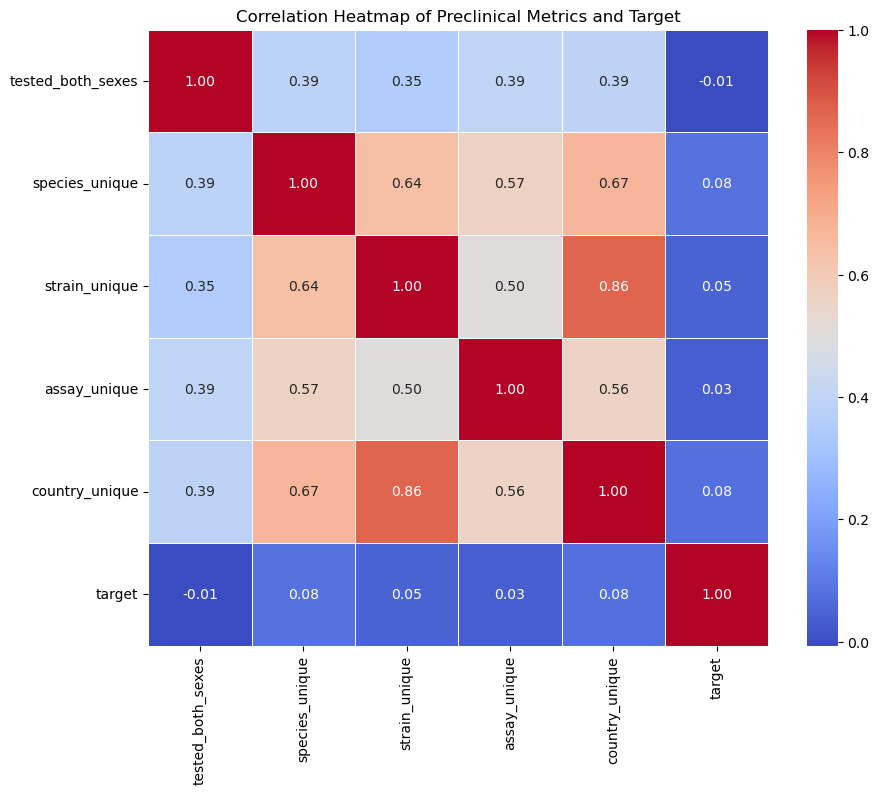

In [352]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Preclinical Metrics and Target')
plt.show()

In [358]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
df = all_entities.copy()
# Prepare data
X = df[['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes']]
y = df['target']

# Standardize (important for comparing coefficients)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit model
model = LogisticRegression()
model.fit(X_scaled, y)

# View importance
importance = pd.Series(model.coef_[0], index=X.columns)
print("Feature Importance (Log-Odds):")
print(importance.sort_values(ascending=False))

Feature Importance (Log-Odds):
species_unique       0.205871
strain_unique        0.000613
assay_unique        -0.016262
tested_both_sexes   -0.087504
dtype: float64


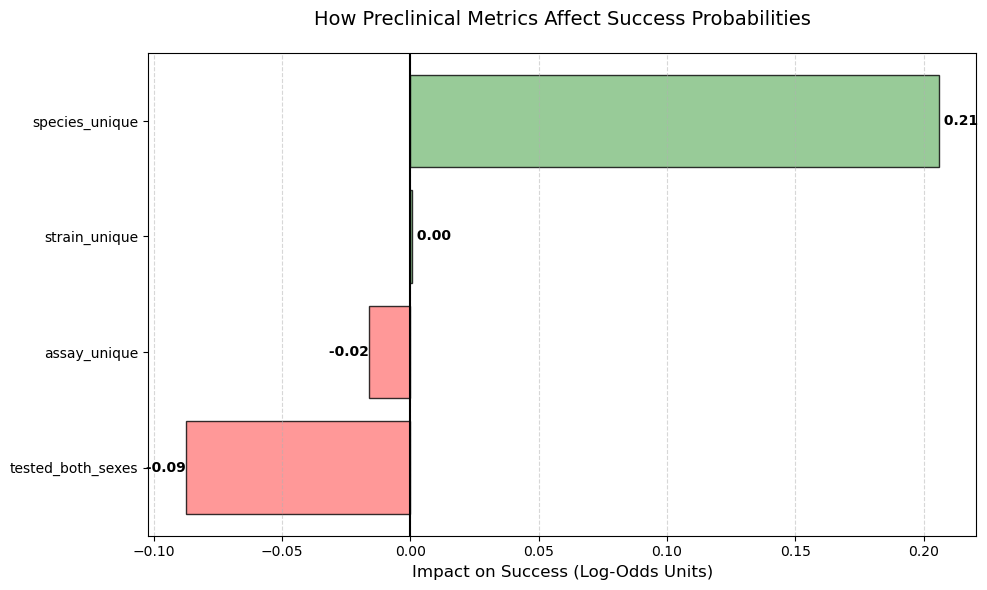

In [360]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare the data
data = {
    'Feature': ['species_unique', 'strain_unique', 'assay_unique', 'tested_both_sexes'],
    'Log-Odds': [0.205871, 0.000613, -0.016262, -0.087504]
}

df_importance = pd.DataFrame(data).sort_values(by='Log-Odds', ascending=True)

# 2. Create the plot
plt.figure(figsize=(10, 6))
# Use green for positive impact and red for negative
colors = ['#ff7f7f' if x < 0 else '#7fbf7f' for x in df_importance['Log-Odds']]
bars = plt.barh(df_importance['Feature'], df_importance['Log-Odds'], color=colors, edgecolor='black', alpha=0.8)

# 3. Add styling
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5) # Reference line at 0
plt.xlabel('Impact on Success (Log-Odds Units)', fontsize=12)
plt.title('How Preclinical Metrics Affect Success Probabilities', fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 4. Label the bars with the actual values
for bar in bars:
    width = bar.get_width()
    label_x_pos = width if width > 0 else width
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, f' {width:.2f}', 
             va='center', ha='left' if width > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_plot.png')